In [46]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [47]:
# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_excel('data1319.xlsx', sheet_name=0)

/Users/charlesyamamura/ls/envs/mlenv/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [48]:
# -----------------------------
# 2. Temporal train/test split
# -----------------------------
train_df = df[df['year'] <= 2018].copy()
test_df  = df[df['year'] == 2019].copy()

In [49]:
# Separate features and target
X_train = train_df.drop(columns=['year', 'mo', 'model', 'share'])
y_train = train_df['share'].values.reshape(-1, 1)

In [50]:
X_test = test_df.drop(columns=['year', 'mo', 'model', 'share'])
y_test = test_df['share'].values.reshape(-1, 1)

In [51]:
# -----------------------------
# 3. Preprocessing (scaling)
# -----------------------------
input_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

In [52]:
X_train_scaled = input_scaler.fit_transform(X_train)
X_test_scaled  = input_scaler.transform(X_test)

In [53]:
y_train_scaled = target_scaler.fit_transform(y_train)
y_test_scaled  = target_scaler.transform(y_test)

In [54]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor  = torch.FloatTensor(X_test_scaled)
y_test_tensor  = torch.FloatTensor(y_test_scaled)

In [55]:
# -----------------------------
# 4. Define the neural network
# -----------------------------
class MLPRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLPRegressor, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

In [56]:
input_size = X_train_tensor.shape[1]
hidden_size = 10
output_size = y_train_tensor.shape[1]

In [57]:
model = MLPRegressor(input_size, hidden_size, output_size)

In [58]:
# -----------------------------
# 5. Loss and optimizer
# -----------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [59]:
# -----------------------------
# 6. Training loop
# -----------------------------
num_epochs = 100
batch_size = 10
history = {'loss': []}

In [60]:
for epoch in range(num_epochs):
    permutation = torch.randperm(X_train_tensor.size()[0])
    epoch_loss = 0.0
    
    for i in range(0, X_train_tensor.size()[0], batch_size):
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_x.size(0)
        
    epoch_loss /= X_train_tensor.size(0)
    history['loss'].append(epoch_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.6f}")

Epoch [10/100], Loss: 0.008149
Epoch [20/100], Loss: 0.007456
Epoch [30/100], Loss: 0.007148
Epoch [40/100], Loss: 0.007196
Epoch [50/100], Loss: 0.006885
Epoch [60/100], Loss: 0.007454
Epoch [70/100], Loss: 0.007205
Epoch [80/100], Loss: 0.006951
Epoch [90/100], Loss: 0.008164
Epoch [100/100], Loss: 0.007063


In [61]:
# -----------------------------
# 7. Predictions
# -----------------------------
with torch.no_grad():
    train_pred_scaled = model(X_train_tensor).numpy()
    test_pred_scaled  = model(X_test_tensor).numpy()

In [62]:
train_pred = target_scaler.inverse_transform(train_pred_scaled)
test_pred  = target_scaler.inverse_transform(test_pred_scaled)

In [63]:
# -----------------------------
# 8. Performance evaluation
# -----------------------------
train_mse = np.mean((train_pred_scaled - y_train_scaled)**2)
test_mse  = np.mean((test_pred_scaled - y_test_scaled)**2)
target_variance = np.var(y_train_scaled)

In [64]:
train_accuracy = max(0, 1 - (train_mse / target_variance))
test_accuracy  = max(0, 1 - (test_mse / target_variance))

In [65]:
train_r2 = r2_score(y_train, train_pred)
test_r2  = r2_score(y_test, test_pred)

In [66]:
print("\nPerformance Results:")
print("Test MSE:", test_mse)
print("Adjusted Training Accuracy:", train_accuracy)
print("Adjusted Testing Accuracy:", test_accuracy)
print("Training R-squared:", train_r2)
print("Testing R-squared:", test_r2)


Performance Results:
Test MSE: 0.034411653330480615
Adjusted Training Accuracy: 0.8239002103042363
Adjusted Testing Accuracy: 0.3288867026403366
Training R-squared: 0.8239001991175801
Testing R-squared: 0.4065565141577442


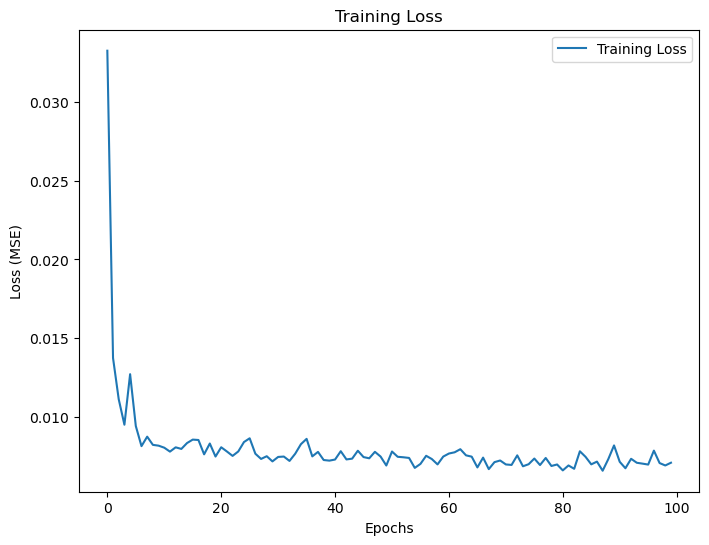

In [67]:
# -----------------------------
# 9. Plot training loss
# -----------------------------
plt.figure(figsize=(8,6))
plt.plot(history['loss'], label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss')
plt.legend()
plt.show()

In [68]:
# -----------------------------
# 10. Deployment function
# -----------------------------
def my_neural_network_function(new_X):
    new_X_scaled = input_scaler.transform(new_X)
    new_X_tensor = torch.FloatTensor(new_X_scaled)
    with torch.no_grad():
        y_scaled = model(new_X_tensor).numpy()
    return target_scaler.inverse_transform(y_scaled)